In [18]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Ensure output directory exists
Path("output").mkdir(parents=True, exist_ok=True)



In [19]:
con = duckdb.connect("data/db.duckdb")



In [20]:
query = """
SELECT
    r.Region,
    c.state_code,
    c.distress_rate as cdc_mental_distress,
    c.avg_income_score as state_income,
    c.income_stddev as state_income_inequality,
    p.mobile_usage_rate as prolific_mobile_rate,
    p.depression_rate as prolific_depression,
    p.count as prolific_sample_size
FROM cdc_state_summary c
JOIN prolific_state_summary p ON p.state_name = (SELECT State FROM regions WHERE "State Code" = c.state_code)
JOIN regions r ON r."State Code" = c.state_code
"""
df = con.execute(query).df()




Saved depression correlation plot to output/depression_correlation.png
--- Robustness Test 2: The Inequality Hypothesis ---


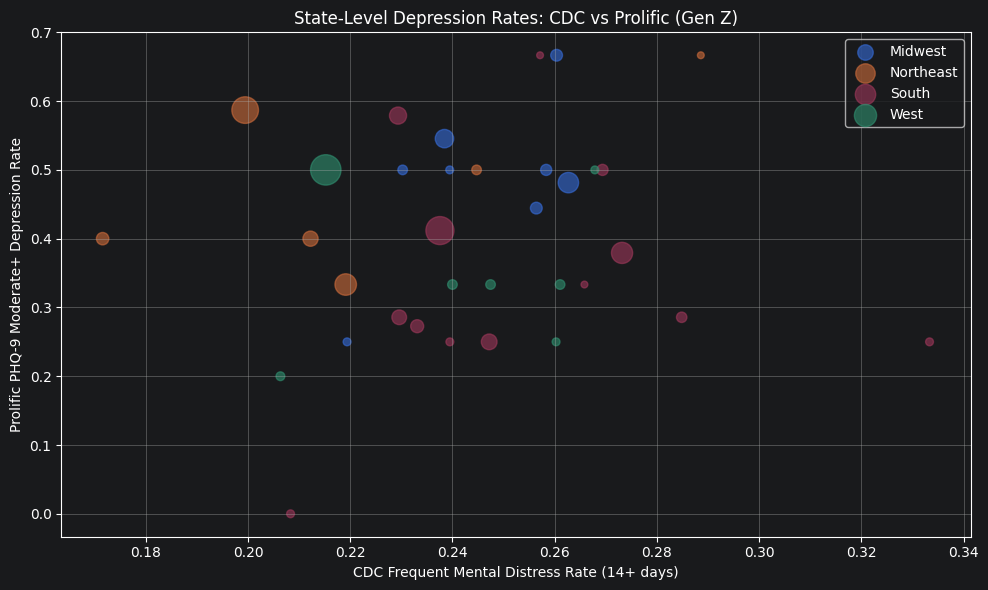

In [21]:
plot_df = df[df["prolific_sample_size"] >= 3].copy()
fig, ax = plt.subplots(figsize=(10, 6))
region_colors = {
    "Midwest": "C0",
    "Northeast": "C1",
    "South": "C2",
    "West": "C3",
}
region_order = ["Midwest", "Northeast", "South", "West"]

for region in region_order:
    region_df = plot_df[plot_df["Region"] == region]
    if region_df.empty:
        continue

    ax.scatter(
        region_df["cdc_mental_distress"],
        region_df["prolific_depression"],
        s=region_df["prolific_sample_size"] * 8,
        alpha=0.6,
        color=region_colors.get(region),
        label=region,
    )

ax.set_title("State-Level Depression Rates: CDC vs Prolific (Gen Z)")
ax.set_xlabel("CDC Frequent Mental Distress Rate (14+ days)")
ax.set_ylabel("Prolific PHQ-9 Moderate+ Depression Rate")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig("output/depression_correlation.png")
print("\nSaved depression correlation plot to output/depression_correlation.png")

print("--- Robustness Test 2: The Inequality Hypothesis ---")



In [22]:
X1 = sm.add_constant(df[["prolific_mobile_rate", "state_income"]])
model1 = sm.OLS(df["cdc_mental_distress"], X1).fit()
print("\nModel 1: CDC Distress ~ Mobile Usage Rate + Avg State Income")
print(model1.summary().tables[1])




Model 1: CDC Distress ~ Mobile Usage Rate + Avg State Income
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.3444      0.096      3.575      0.001       0.150       0.539
prolific_mobile_rate     0.0486      0.033      1.478      0.147      -0.018       0.115
state_income            -0.0167      0.015     -1.101      0.278      -0.047       0.014


In [23]:
X2 = sm.add_constant(df[["prolific_mobile_rate", "state_income_inequality"]])
model2 = sm.OLS(df["cdc_mental_distress"], X2).fit()
print("\nModel 2: CDC Distress ~ Mobile Usage Rate + Income Inequality")
print(model2.summary().tables[1])




Model 2: CDC Distress ~ Mobile Usage Rate + Income Inequality
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.4221      0.061      6.873      0.000       0.298       0.546
prolific_mobile_rate        0.0329      0.030      1.099      0.278      -0.028       0.093
state_income_inequality    -0.0791      0.026     -3.004      0.005      -0.132      -0.026


In [24]:
X3 = sm.add_constant(
    df[["prolific_mobile_rate", "state_income", "state_income_inequality"]]
)
model3 = sm.OLS(df["cdc_mental_distress"], X3).fit()
print("\nModel 3: CDC Distress ~ Mobile + Avg Income + Income Inequality")
print(model3.summary().tables[1])




Model 3: CDC Distress ~ Mobile + Avg Income + Income Inequality
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.4630      0.099      4.692      0.000       0.263       0.663
prolific_mobile_rate        0.0358      0.031      1.166      0.251      -0.026       0.098
state_income               -0.0077      0.014     -0.532      0.598      -0.037       0.021
state_income_inequality    -0.0758      0.027     -2.778      0.008      -0.131      -0.021



Saved inequality plot to output/inequality_stress_test.png


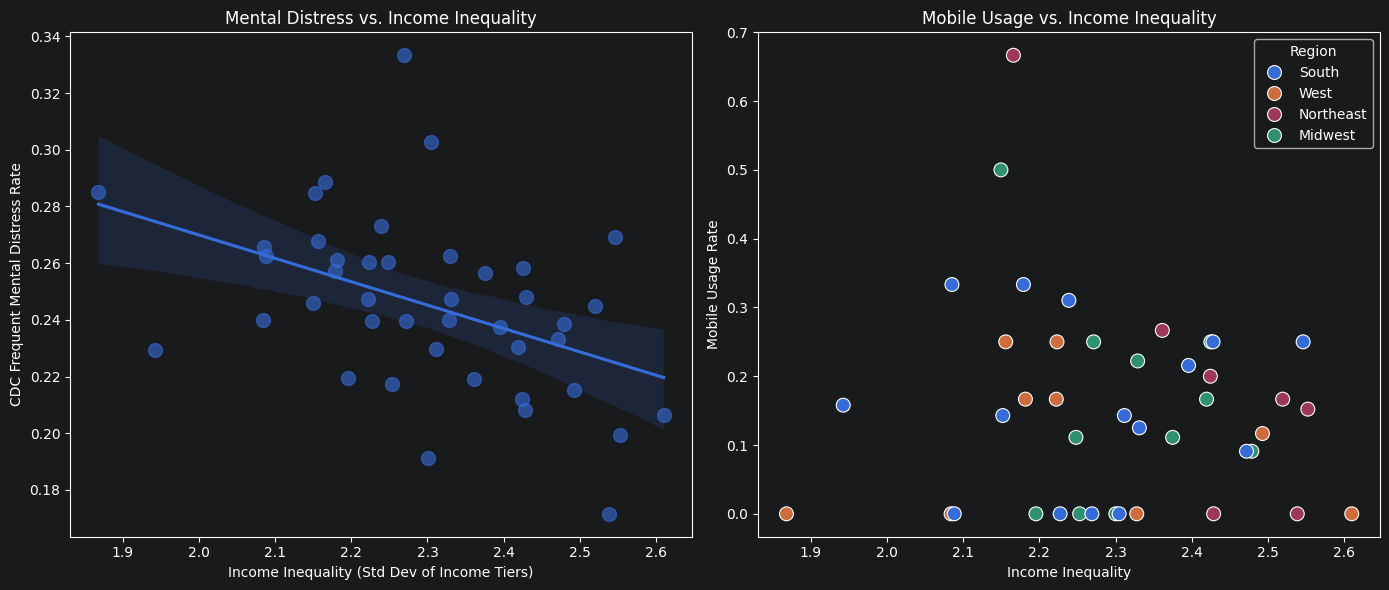

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
sns.regplot(
    data=df,
    x="state_income_inequality",
    y="cdc_mental_distress",
    ax=axs[0],
    scatter_kws={"alpha": 0.6, "s": 100},
)
axs[0].set_title("Mental Distress vs. Income Inequality")
axs[0].set_xlabel("Income Inequality (Std Dev of Income Tiers)")
axs[0].set_ylabel("CDC Frequent Mental Distress Rate")

sns.scatterplot(
    data=df,
    x="state_income_inequality",
    y="prolific_mobile_rate",
    hue="Region",
    s=100,
    ax=axs[1],
)
axs[1].set_title("Mobile Usage vs. Income Inequality")
axs[1].set_xlabel("Income Inequality")
axs[1].set_ylabel("Mobile Usage Rate")

fig.tight_layout()
fig.savefig("output/inequality_stress_test.png")
print("\nSaved inequality plot to output/inequality_stress_test.png")



In [27]:
print("\nInequality Analysis Results:")
print(
    f"P-value for Mobile Rate (in full model): {model3.pvalues['prolific_mobile_rate']:.3f}"
)
print(f"P-value for Avg Income (in full model): {model3.pvalues['state_income']:.3f}")
print(
    f"P-value for Income Inequality (in full model): {model3.pvalues['state_income_inequality']:.3f}"
)

if model3.pvalues["state_income_inequality"] < 0.05:
    print(
        "Finding: Income Inequality is a significant driver of mental distress. 'Structural Isolation' may be tied to economic relative deprivation."
    )
else:
    print(
        "Finding: Income Inequality is not significant at the p<0.05 level in this model."
    )




Inequality Analysis Results:
P-value for Mobile Rate (in full model): 0.251
P-value for Avg Income (in full model): 0.598
P-value for Income Inequality (in full model): 0.008
Finding: Income Inequality is a significant driver of mental distress. 'Structural Isolation' may be tied to economic relative deprivation.


In [28]:
print("\n--- Hypothesis Check: The Homogeneity Trap ---")
query_check = """
SELECT
    r.State,
    ROUND(c.distress_rate, 3) as distress,
    ROUND(c.avg_income_score, 2) as avg_income,
    ROUND(c.income_stddev, 3) as inequality
FROM cdc_state_summary c
JOIN regions r ON c.state_code = r."State Code"
ORDER BY c.income_stddev DESC
"""
df_check = con.execute(query_check).df()
print("High Inequality (Diverse Economies) - Top 5:")
print(df_check.head(5).to_string(index=False))
print("\nLow Inequality (Homogenous Economies) - Bottom 5:")
print(df_check.tail(5).to_string(index=False))

con.close()



--- Hypothesis Check: The Homogeneity Trap ---
High Inequality (Diverse Economies) - Top 5:
         State  distress  avg_income  inequality
        Nevada     0.206        6.33       2.610
      New York     0.199        6.41       2.553
South Carolina     0.269        5.97       2.546
    New Jersey     0.172        6.87       2.539
   Connecticut     0.245        6.58       2.519

Low Inequality (Homogenous Economies) - Bottom 5:
       State  distress  avg_income  inequality
    Oklahoma     0.266        5.65       2.085
  New Mexico     0.240        5.77       2.084
    Virginia     0.229        6.58       1.943
       Idaho     0.285        6.36       1.868
South Dakota     0.215        6.48       1.809
